# Month product-store demand classification with ADI and CV^2

This notebook classifies demand series from `data/processed/transactions_dst_over_months` into **smooth**, **erratic**, **intermittent**, and **lumpy** demand.

The default grain is one demand series per `ARTIKEL_ID` and `MARKT_ID`. For product-level demand aggregated across all stores instead, set `GROUP_COLS = ["ARTIKEL_ID"]`.

`DATE` is interpreted as the first day of the month. Generate the dataset first with `python src/data/preparation/distribute_sales_over_active_months.py`.

## Monthly aggregation tradeoff

Monthly aggregation reduces sparsity further than weekly aggregation and is useful as a stability check for baseline models. The tradeoff is temporal resolution: monthly demand can be too coarse for operational decisions that need weekly or daily replenishment timing. Treat monthly results as a low-frequency benchmark, not as a replacement for the operational forecast grain unless that matches the use case.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE"
MIN_DEMAND_PERIODS = 10
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

candidate_dirs = [
    Path("../../data/processed/transactions_dst_over_months"),
    Path("../data/processed/transactions_dst_over_months"),
    Path("data/processed/transactions_dst_over_months"),
]
DATA_DIR = next((path for path in candidate_dirs if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the processed month transactions directory. "
        "Run src/data/preparation/distribute_sales_over_active_months.py first."
    )

parquet_files = sorted(DATA_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")

print(f"Using {len(parquet_files)} parquet files from {DATA_DIR}")
print(f"Classifying demand series at grain: {', '.join(GROUP_COLS)}")

Using 6 parquet files from ../../data/processed/transactions_dst_over_months
Classifying demand series at grain: ARTIKEL_ID, MARKT_ID


## Method

For each demand series:

- **ADI** is `active_months / demand_months`, where demand months have sold quantity above zero.
- **CV^2** is `variance(non-zero demand) / mean(non-zero demand)^2`.
- **Smooth**: `ADI < 1.32` and `CV^2 < 0.49`.
- **Erratic**: `ADI < 1.32` and `CV^2 >= 0.49`.
- **Intermittent**: `ADI >= 1.32` and `CV^2 < 0.49`.
- **Lumpy**: `ADI >= 1.32` and `CV^2 >= 0.49`.

Rows with zero sold amount are retained as active no-sale months, as intended by the prepared data. Series with fewer than `MIN_DEMAND_PERIODS` demand months are excluded from the summary.

In [2]:
group_cols_sql = ", ".join(GROUP_COLS)
period_group_cols_sql = ", ".join([*GROUP_COLS, "period_start"])
parquet_glob = str(DATA_DIR / "*.parquet")

query = f"""
WITH raw AS (
    SELECT
        {group_cols_sql},
        CAST(DATE AS DATE) AS period_start,
        CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand
    FROM read_parquet(?)
), period_data AS (
    SELECT
        {period_group_cols_sql},
        SUM(demand) AS demand
    FROM raw
    GROUP BY {period_group_cols_sql}
), series AS (
    SELECT
        {group_cols_sql},
        COUNT(*) AS active_months,
        SUM(CASE WHEN demand > 0 THEN 1 ELSE 0 END) AS demand_months,
        SUM(demand) AS series_total_demand,
        AVG(CASE WHEN demand > 0 THEN demand END) AS mean_nonzero_demand,
        VAR_SAMP(CASE WHEN demand > 0 THEN demand END) AS var_nonzero_demand,
        MIN(period_start) AS first_active_month,
        MAX(period_start) AS last_active_month
    FROM period_data
    GROUP BY {group_cols_sql}
)
SELECT
    *,
    active_months / NULLIF(demand_months, 0) AS ADI,
    CASE
        WHEN demand_months > 1 AND mean_nonzero_demand > 0
            THEN var_nonzero_demand / (mean_nonzero_demand * mean_nonzero_demand)
        WHEN demand_months = 1 THEN 0.0
        ELSE NULL
    END AS CV2
FROM series
WHERE demand_months > 0
"""

con = duckdb.connect()
series_metrics = con.execute(query, [parquet_glob]).fetchdf()
series_metrics.head()

,ARTIKEL_ID,MARKT_ID,active_months,demand_months,series_total_demand,mean_nonzero_demand,var_nonzero_demand,first_active_month,last_active_month,ADI,CV2
0,289212,1250031,60,53.0,64.264,1.212528,0.998170,2021-07-01,2026-06-01,1.132075,0.678923
1,967754,1350051,22,22.0,96.330,4.378636,1.890232,2021-06-01,2023-03-01,1.000000,0.098591
2,301070,1150007,61,61.0,305.868,5.014230,7.199653,2021-06-01,2026-06-01,1.000000,0.286354
3,308272,1100031,16,16.0,34.492,2.155750,1.439547,2021-07-01,2022-10-01,1.000000,0.309763
4,308273,1250045,61,59.0,109.066,1.848576,1.865415,2021-06-01,2026-06-01,1.033898,0.545884


In [3]:
conditions = [
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
]
choices = ["smooth", "erratic", "intermittent", "lumpy"]

series_classification = series_metrics.assign(
    demand_class=np.select(conditions, choices, default="unclassified")
)
series_classification = series_classification[
    series_classification["demand_months"] >= MIN_DEMAND_PERIODS
]

class_order = ["smooth", "erratic", "intermittent", "lumpy"]
class_palette = {
    "smooth": "#2a9d8f",
    "erratic": "#e9c46a",
    "intermittent": "#457b9d",
    "lumpy": "#d62828",
}

product_agg = ("ARTIKEL_ID", "nunique") if "ARTIKEL_ID" in GROUP_COLS else (GROUP_COLS[0], "nunique")
summary = (
    series_classification
    .groupby("demand_class", observed=True)
    .agg(
        series=(GROUP_COLS[0], "size"),
        products=product_agg,
        active_months=("active_months", "sum"),
        demand_months=("demand_months", "sum"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
    )
    .reindex(class_order)
)
summary["series_share"] = summary["series"] / summary["series"].sum()
summary["observation_share"] = summary["active_months"] / summary["active_months"].sum()

summary_display = summary.copy()
for col in ["series_share", "observation_share"]:
    summary_display[col] = (summary_display[col] * 100).round(1)
summary_display[["median_ADI", "median_CV2"]] = summary_display[["median_ADI", "median_CV2"]].round(2)
summary_display.rename(
    columns={
        "series_share": "series_share_%",
        "observation_share": "observation_share_%",
    }
)

,series,products,active_months,demand_months,median_ADI,median_CV2,series_share_%,observation_share_%
demand_class,,,,,,,,
smooth,58231,3282,2585419,2506368.0,1.00,0.23,39.2,38.4
erratic,23024,1832,1032450,941177.0,1.08,0.70,15.5,15.3
intermittent,23169,2030,1042059,505602.0,2.00,0.36,15.6,15.5
lumpy,44139,2320,2077117,974042.0,2.11,0.80,29.7,30.8


In [4]:
regular_share = summary.loc[["smooth", "erratic"], "series"].sum() / summary["series"].sum()
sparse_share = summary.loc[["intermittent", "lumpy"], "series"].sum() / summary["series"].sum()
zero_period_share = 1 - (series_classification["demand_months"].sum() / series_classification["active_months"].sum())

print(f"Total classified series: {len(series_classification):,}")
print(f"Regular-demand share (smooth + erratic): {regular_share:.1%}")
print(f"Sparse-demand share (intermittent + lumpy): {sparse_share:.1%}")
print(f"Zero active-period share: {zero_period_share:.1%}")

Total classified series: 148,563
Regular-demand share (smooth + erratic): 54.7%
Sparse-demand share (intermittent + lumpy): 45.3%
Zero active-period share: 26.9%


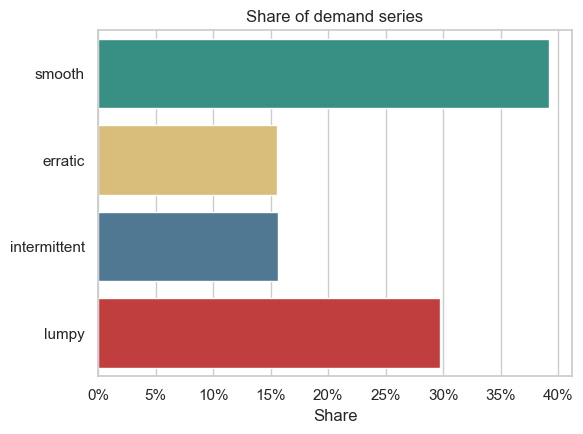

In [5]:
plot_summary = summary.reset_index()

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.barplot(
    data=plot_summary,
    y="demand_class",
    x="series_share",
    order=class_order,
    palette=class_palette,
    hue="demand_class",
    hue_order=class_order,
    legend=False,
    ax=ax,
)

ax.set_title("Share of demand series")
ax.set_xlabel("Share")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()

In [6]:
quantiles = (
    series_classification
    .groupby("demand_class", observed=True)[["ADI", "CV2", "active_months", "demand_months"]]
    .quantile([0.25, 0.50, 0.75])
    .round(2)
)
quantiles

ADI   CV2  active_months  demand_months
demand_class                                               
erratic      0.25  1.00  0.58           27.0           24.0
             0.50  1.08  0.70           55.0           47.0
             0.75  1.18  0.91           60.0           56.0
intermittent 0.25  1.59  0.28           36.0           13.0
             0.50  2.00  0.36           48.0           19.0
             0.75  2.80  0.43           56.0           29.0
lumpy        0.25  1.64  0.62           39.0           14.0
             0.50  2.11  0.80           51.0           20.0
             0.75  2.92  1.14           58.0           29.0
smooth       0.25  1.00  0.14           28.0           27.0
             0.50  1.00  0.23           52.0           49.0
             0.75  1.03  0.33           61.0           60.0

## Baseline implication

Use this month product-store classification to decide which baselines are fair:

- smooth/erratic series can be evaluated with simple seasonal naive and moving-average baselines;
- intermittent/lumpy series need sparse-demand baselines such as zero, last non-zero demand, Croston/SBA/TSB-style methods, or a two-stage demand-occurrence plus demand-size baseline;
- compare direct product-store forecasting against a product-level forecast allocated to stores by recent store shares.